# 0. Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Import Libraries

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session

# 2. Load Split Dataset

In [ ]:
import sys

project_dir = "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification"
sys.path.append(project_dir)

from utils import load_animals10_datasets

train_dataset, val_dataset, test_dataset, class_names = load_animals10_datasets()

Using Colab cache for faster access to the 'animals10' dataset.


### Check Data

In [ ]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

print(class_names)

(32, 128, 128, 3)
(32, 10)
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# 3. Define Model

In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

num_classes = 10
input_shape= (128, 128, 3)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
])


model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        data_augmentation,
        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.2),

        layers.Conv2D(128, kernel_size=(3,3), activation="relu"),
        layers.Conv2D(128, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.Conv2D(128, kernel_size=(3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,178,058 (12.12 MB)

 Trainable params: 3,178,058 (12.12 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Compile and Train Model

In [ ]:
import time
from keras.optimizers import Adam

epochs = 30
my_opt = Adam(learning_rate=0.0001)

model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt,
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Track train time: starting timing
start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)
# Track train time: end timing
end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 87s 114ms/step - accuracy: 0.1766 - loss: 2.2681 - val_accuracy: 0.1856 - val_loss: 2.2198
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 69s 106ms/step - accuracy: 0.1845 - loss: 2.2245 - val_accuracy: 0.1856 - val_loss: 2.2150
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 102ms/step - accuracy: 0.1844 - loss: 2.2205 - val_accuracy: 0.1856 - val_loss: 2.2122
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 103ms/step - accuracy: 0.1857 - loss: 2.2177 - val_accuracy: 0.1856 - val_loss: 2.2112
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.1885 - loss: 2.2186 - val_accuracy: 0.1910 - val_loss: 2.2095
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 103ms/step - accuracy: 0.1799 - loss: 2.2166 - val_accuracy: 0.1856 - val_loss: 2.2087
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 66s 101ms/step - accuracy: 0.1816 - loss: 2.2151 - val_accuracy: 0.1856 - val_loss: 2.2090
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 102ms/step - accuracy: 0.1838 - loss: 2

# 5. Evaluate Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Test accuracy: {accuracy}")
print(f"Test precision: {precision}")
print(f"Test recall: {recall}")
print(f"Confusion Matrix: \n {cm}")

Test accuracy: 0.1703590527119939
Test precision: 0.1350171423052779
Test recall: 0.0928533788189895
Confusion Matrix: 
 [[224   0   0   0   0   0   0   0 263   0]
 [ 60   0   0   0   0   0   0   0 202   0]
 [ 55   0   0   0   0   0   0   0  90   0]
 [ 61   0   0   3   0   0   0   0 147   0]
 [ 96   0   0   0   0   0   0   0 214   0]
 [ 91   0   0   0   0   0   1   0  75   0]
 [ 55   0   0   0   0   0   0   0 131   0]
 [ 79   0   0   0   0   0   0   0 103   0]
 [263   0   0   0   0   0   0   0 219   0]
 [ 96   0   0   0   0   0   0   0  90   0]]


# 6.Plot Loss and Accuracy

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

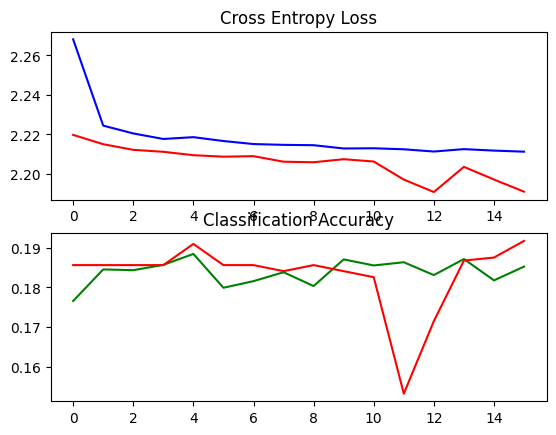

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='red', label='validation')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.plot(history.history['val_accuracy'], color='red', label='validation')
plt.show()

# 6.2 Plot Comfusion Matrix

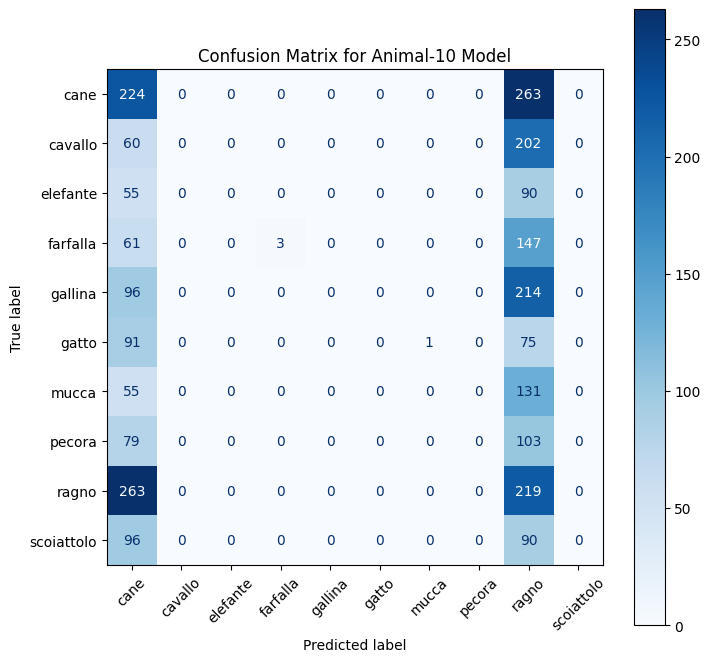

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix for Animal-10 Model")
plt.show()

# 7. Save Model

In [ ]:
model.save("/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_8_data_augmentation_wider.keras")

print("Model Saved")

Model Saved


In [ ]:
# how to import model when needed

'''
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_8_data_augmentation_wider.keras"
)
'''

'\nimport tensorflow as tf\n\nmodel = tf.keras.models.load_model(\n    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_3_wider_cnn.keras"\n)\n'